# 卷積

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage
from scipy.signal import convolve2d
from skimage.exposure import rescale_intensity

## 範例1. 使用程式計算卷積

In [2]:
# 測試資料
source_map = np.array(list('1110001110001110011001100')).astype(int)
source_map = source_map.reshape(5, 5)
print('原始資料：')
print(source_map)

# 濾波器(Filter)
filter1 = np.array(list('101010101')).astype(int).reshape(3, 3)
print('\n濾波器:')
print(filter1)

原始資料：
[[1 1 1 0 0]
 [0 1 1 1 0]
 [0 0 1 1 1]
 [0 0 1 1 0]
 [0 1 1 0 0]]

濾波器:
[[1 0 1]
 [0 1 0]
 [1 0 1]]


In [3]:
# 計算卷積
# 初始化計算結果的矩陣
width = height = source_map.shape[0] - filter1.shape[0] + 1
result = np.zeros((width, height))

# 計算每一格
for i in range(width):
    for j in range(height):
        value1 = source_map[i : i + filter1.shape[0], j : j + filter1.shape[1]] * filter1
        result[i, j] = np.sum(value1)
print(result)

[[4. 3. 4.]
 [2. 4. 3.]
 [2. 3. 4.]]


In [4]:
# 使用 scipy 計算卷積
# convolve2d：二維卷積
convolve2d(source_map, filter1, mode='valid')

array([[4, 3, 4],
       [2, 4, 3],
       [2, 3, 4]])

## 定義卷積的影像轉換函數

In [5]:
# 卷積的影像轉換函數，padding='same'
def convolve(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    # 取得圖像與濾波器的寬高
    iH, iW = image.shape[:2]
    kH, kW = kernel.shape[:2]

    # 計算 padding='same' 單邊所需的補零行數
    pad = int((kW - 1) / 2)
    image = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REPLICATE)
    output = np.zeros((iH, iW), dtype="float32")

    # 卷積
    for y in np.arange(pad, iH + pad):
        for x in np.arange(pad, iW + pad):
            roi = image[y - pad : y + pad + 1, x - pad : x + pad + 1]  # 裁切圖像
            k = (roi * kernel).sum()  # 卷積計算
            output[y - pad, x - pad] = k  # 更新計算結果的矩陣

    # 調整影像色彩深淺範圍至 (0, 255)
    output = rescale_intensity(output, in_range='uint8')
    output = (output * 255).astype("uint8")

    return output  # 回傳結果影像

## 灰階化(Gray)

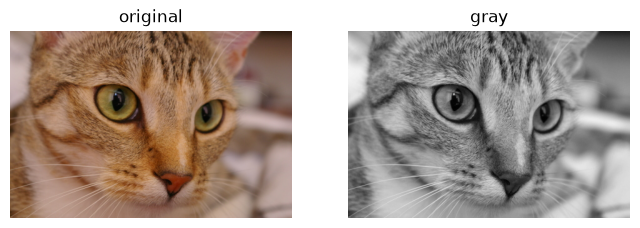

In [6]:
# pip install opencv-python
# 自 skimage 取得內建的圖像
image = skimage.data.chelsea()

# 灰階化
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("original")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("gray")
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

## 模糊化(Blur)

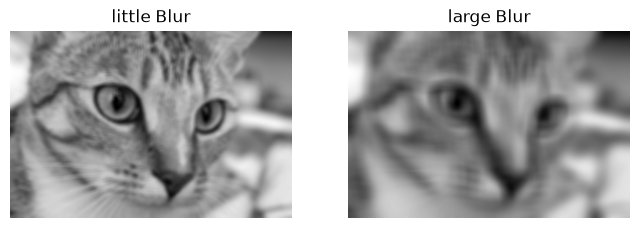

In [7]:
# 小模糊 filter
smallBlur = np.ones((7, 7), dtype="float") * (1.0 / (7 * 7))

# 卷積
littleBlurOutput = convolve(gray, smallBlur)

# 大模糊
largeBlur = np.ones((21, 21), dtype="float") * (1.0 / (21 * 21))

# 卷積
largeBlurOutput = convolve(gray, largeBlur)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("little Blur")
plt.imshow(littleBlurOutput, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("large Blur")
plt.imshow(largeBlurOutput, cmap="gray")
plt.axis("off")
plt.show()

## 銳化(sharpen)

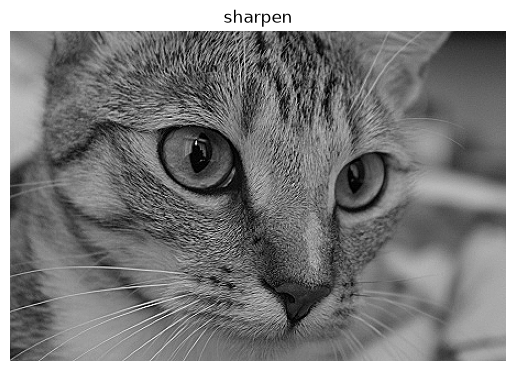

In [8]:
# sharpening filter
sharpen = np.array((
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]), dtype="int")

# 卷積
convoleOutput = convolve(gray, sharpen)

plt.figure()
plt.title("sharpen")
plt.imshow(convoleOutput, cmap="gray")
plt.axis("off")
plt.show()

## Laplacian 邊緣偵測

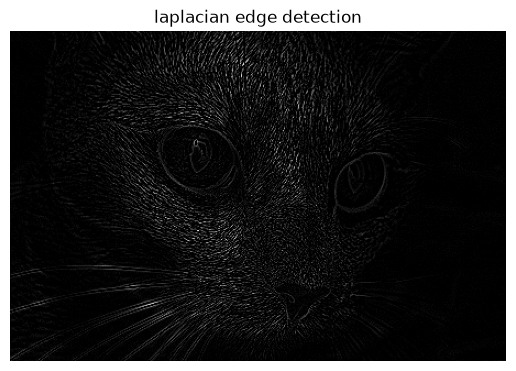

In [9]:
# Laplacian filter
laplacian = np.array((
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]), dtype="int")

# 卷積
convoleOutput = convolve(gray, laplacian)

plt.figure()
plt.title("laplacian edge detection")
plt.imshow(convoleOutput, cmap="gray")
plt.axis("off")
plt.show()

## Sobel X軸邊緣偵測

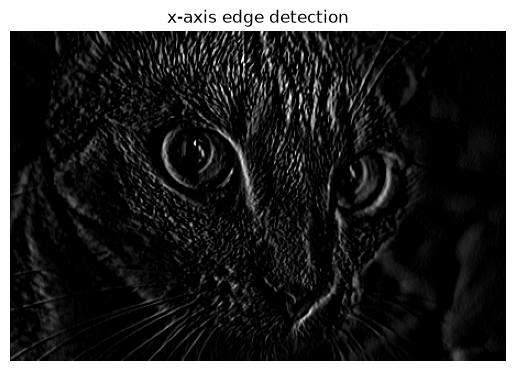

In [10]:
# Sobel x-axis filter
sobelX = np.array((
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]), dtype="int")

# 卷積
convoleOutput = convolve(gray, sobelX)

plt.figure()
plt.title("x-axis edge detection")
plt.imshow(convoleOutput, cmap="gray")
plt.axis("off")
plt.show()

## Sobel Y軸邊緣偵測

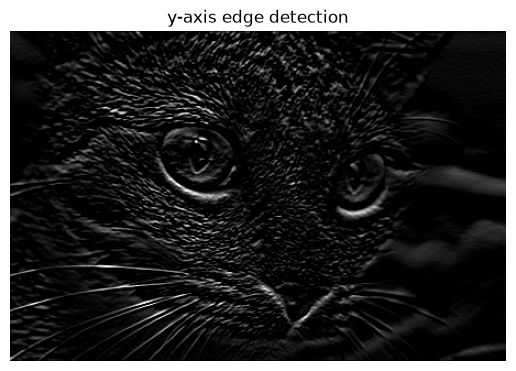

In [11]:
# Sobel y-axis filter
sobelY = np.array((
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]), dtype="int")

# 卷積
convoleOutput = convolve(gray, sobelY)

plt.figure()
plt.title("y-axis edge detection")
plt.imshow(convoleOutput, cmap="gray")
plt.axis("off")
plt.show()